# 🎯 Módulo 13: Seleção de Variáveis

## Objetivos de Aprendizagem

Ao final deste módulo, você será capaz de:

- ✅ Compreender por que a seleção de variáveis é essencial em ML
- ✅ Aplicar **Filter Methods** (F-Score, Informação Mútua, Cramer's V)
- ✅ Usar **Wrapper Methods** (RFE — Recursive Feature Elimination)
- ✅ Implementar **Embedded Methods** (LASSO, importância de árvores)
- ✅ Comparar métodos e construir consenso entre diferentes seletores
- ✅ Encontrar o número ótimo de features pela curva performance × n_features

---

## Estrutura do Módulo

1. Teoria: Filter, Wrapper e Embedded Methods
2. Filter Methods — Seleção Independente do Modelo
3. Wrapper e Embedded Methods (RFE, LASSO, RF MDI)
4. Curva de Performance × Número de Features
5. Resumo e Exercícios

---

> **Problema da Dimensionalidade:** Mais features nem sempre significa melhor modelo. Features irrelevantes adicionam ruído, aumentam o tempo de treino e podem piorar a generalização.

## 2. Teoria e Equações

### Métodos de Seleção

**Filter Methods** (independentes do modelo):
$$\text{Cramer's V} = \sqrt{\frac{\chi^2}{n \cdot \min(r-1, c-1)}}$$
$$\text{Fisher Score: } F(X_j) = \frac{\sum_k n_k (\mu_k^{(j)} - \mu^{(j)})^2}{\sum_k n_k (\sigma_k^{(j)})^2}$$
$$\text{Ganho de Informação: } IG(X, y) = H(y) - H(y|X)$$

**Wrapper Methods** (usam o modelo):
- Forward Selection: começa vazio, adiciona a melhor feature a cada passo
- Backward Elimination: começa com todas, remove a pior
- Stepwise: combina forward e backward

**Critérios de Seleção de Modelo:**
$$AIC = 2k - 2\ln(\hat{L}) \quad \text{(penaliza parâmetros)}$$
$$BIC = k\ln(n) - 2\ln(\hat{L}) \quad \text{(penaliza mais fortemente)}$$

**Embedded Methods** (seleção durante o treinamento):
- LASSO: zera coeficientes de features irrelevantes
- Tree-based: importância Gini/MDI
- RFE: Recursive Feature Elimination

### Comparação dos Métodos

| Método | Custo Computacional | Risco de Overfitting | Considera Interações |
|--------|--------------------|--------------------|--------------------|
| Filter | Baixo | Nenhum | Não |
| Wrapper | Alto | Alto | Sim (parcialmente) |
| Embedded | Médio | Baixo | Sim (parcialmente) |

📊 FILTER METHODS — SELEÇÃO SEM MODELO


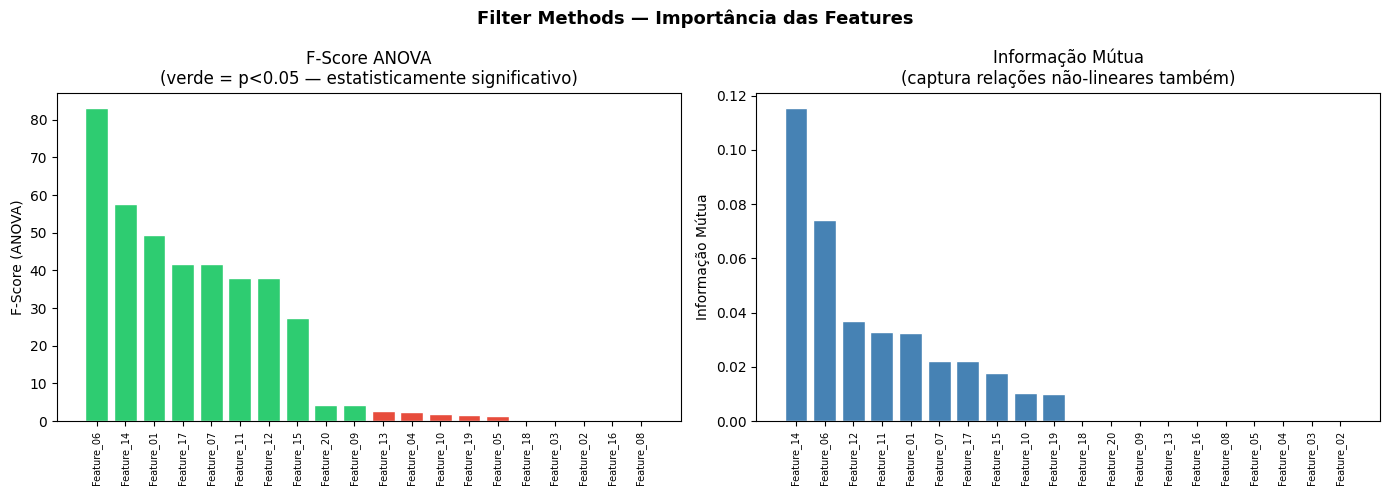


Top 5 features por F-Score:
  Feature_06: F=83.05, p=0.0000
  Feature_14: F=57.57, p=0.0000
  Feature_01: F=49.50, p=0.0000
  Feature_17: F=41.71, p=0.0000
  Feature_07: F=41.71, p=0.0000


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif,
                                        RFE, SelectFromModel, VarianceThreshold)
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Dataset com mix de features relevantes e irrelevantes
X_sel, y_sel = make_classification(
    n_samples=1000, n_features=20, n_informative=8, n_redundant=4, 
    n_repeated=2, n_clusters_per_class=2, random_state=42
)
feat_nomes = [f'Feature_{i+1:02d}' for i in range(20)]
X_df_sel = pd.DataFrame(X_sel, columns=feat_nomes)

X_tr, X_te, y_tr, y_te = train_test_split(X_df_sel, y_sel, test_size=0.25, stratify=y_sel, random_state=42)

print("=" * 55)
print("📊 FILTER METHODS — SELEÇÃO SEM MODELO")
print("=" * 55)

# ANOVA F-score
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

f_scores, p_values = f_classif(X_tr_sc, y_tr)
mi_scores = mutual_info_classif(X_tr_sc, y_tr, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Filter Methods — Importância das Features', fontsize=13, fontweight='bold')

# F-score
idx_fscore = np.argsort(f_scores)[::-1]
colors_sig = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in p_values[idx_fscore]]
axes[0].bar(range(20), f_scores[idx_fscore], color=colors_sig, edgecolor='white')
axes[0].set_xticks(range(20))
axes[0].set_xticklabels([feat_nomes[i] for i in idx_fscore], rotation=90, fontsize=7)
axes[0].set_ylabel('F-Score (ANOVA)'); axes[0].set_title('F-Score ANOVA\n(verde = p<0.05 — estatisticamente significativo)')

# Mutual Information
idx_mi = np.argsort(mi_scores)[::-1]
axes[1].bar(range(20), mi_scores[idx_mi], color='steelblue', edgecolor='white')
axes[1].set_xticks(range(20))
axes[1].set_xticklabels([feat_nomes[i] for i in idx_mi], rotation=90, fontsize=7)
axes[1].set_ylabel('Informação Mútua'); axes[1].set_title('Informação Mútua\n(captura relações não-lineares também)')

plt.tight_layout()
plt.savefig('../imagens/13_filter_methods.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features por F-Score:")
for i in range(5):
    print(f"  {feat_nomes[idx_fscore[i]]}: F={f_scores[idx_fscore[i]]:.2f}, p={p_values[idx_fscore[i]]:.4f}")

In [2]:
print("=" * 55)
print("🔄 WRAPPER E EMBEDDED METHODS")
print("=" * 55)

# RFE com Random Forest
rf_base = RandomForestClassifier(n_estimators=50, random_state=42)
rfe = RFE(rf_base, n_features_to_select=8, step=2)
rfe.fit(X_tr_sc, y_tr)
features_rfe = [feat_nomes[i] for i in range(20) if rfe.support_[i]]
print(f"\nRFE seleciona {len(features_rfe)} features: {features_rfe}")

# LASSO embedded
lasso_sel = SelectFromModel(Lasso(alpha=0.01), max_features=10)
lasso_sel.fit(X_tr_sc, y_tr)
features_lasso = [feat_nomes[i] for i in range(20) if lasso_sel.get_support()[i]]
print(f"\nLASSO seleciona {len(features_lasso)} features: {features_lasso}")

# RF MDI importance
rf_fi = RandomForestClassifier(n_estimators=200, random_state=42)
rf_fi.fit(X_tr_sc, y_tr)
fi = rf_fi.feature_importances_
features_rf_top8 = [feat_nomes[i] for i in np.argsort(fi)[::-1][:8]]
print(f"\nRF MDI top-8: {features_rf_top8}")

# Tabela: feature × método
metodos = {
    'F-Score (top 8)': set([feat_nomes[i] for i in idx_fscore[:8]]),
    'MI (top 8)': set([feat_nomes[i] for i in idx_mi[:8]]),
    'RFE': set(features_rfe),
    'LASSO': set(features_lasso),
    'RF MDI (top 8)': set(features_rf_top8),
}

tabela = pd.DataFrame({metodo: [feat in feats for feat in feat_nomes] 
                         for metodo, feats in metodos.items()}, 
                        index=feat_nomes).replace({True: '✓', False: ''})
tabela['Votos'] = sum(tabela[m] == '✓' for m in metodos.keys())
tabela = tabela.sort_values('Votos', ascending=False)

print("\n📊 Tabela Feature × Método:")
display(tabela)

🔄 WRAPPER E EMBEDDED METHODS

RFE seleciona 8 features: ['Feature_01', 'Feature_06', 'Feature_07', 'Feature_10', 'Feature_12', 'Feature_14', 'Feature_15', 'Feature_16']

LASSO seleciona 9 features: ['Feature_01', 'Feature_07', 'Feature_10', 'Feature_12', 'Feature_13', 'Feature_14', 'Feature_15', 'Feature_17', 'Feature_19']

RF MDI top-8: ['Feature_14', 'Feature_10', 'Feature_06', 'Feature_12', 'Feature_15', 'Feature_07', 'Feature_17', 'Feature_19']

📊 Tabela Feature × Método:


,F-Score (top 8),MI (top 8),RFE,LASSO,RF MDI (top 8),Votos
Feature_14,✓,✓,✓,✓,✓,5
Feature_15,✓,✓,✓,✓,✓,5
Feature_12,✓,✓,✓,✓,✓,5
Feature_07,✓,✓,✓,✓,✓,5
Feature_06,✓,✓,✓,,✓,4
Feature_17,✓,✓,,✓,✓,4
Feature_01,✓,✓,✓,✓,,4
Feature_10,,,✓,✓,✓,3
Feature_19,,,,✓,✓,2
Feature_11,✓,✓,,,,2


📈 PERFORMANCE VS NÚMERO DE FEATURES


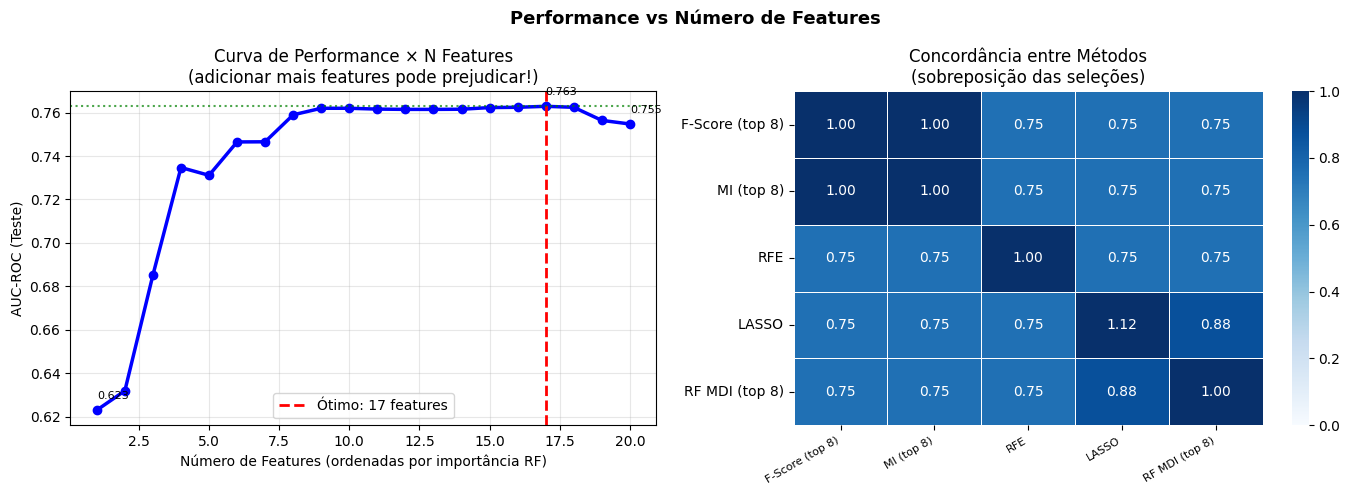

✅ Melhor desempenho com 17 features (AUC=0.7629)


In [3]:
print("=" * 55)
print("📈 PERFORMANCE VS NÚMERO DE FEATURES")
print("=" * 55)

# Ordenar features por importância de RF
fi_order = np.argsort(rf_fi.feature_importances_)[::-1]

auc_n_features = []
for n in range(1, 21):
    feat_idx = fi_order[:n]
    X_tr_n = X_tr_sc[:, feat_idx]
    X_te_n = X_te_sc[:, feat_idx]
    
    lr = LogisticRegression(random_state=42, max_iter=500)
    lr.fit(X_tr_n, y_tr)
    auc = roc_auc_score(y_te, lr.predict_proba(X_te_n)[:,1])
    auc_n_features.append(auc)

melhor_n = np.argmax(auc_n_features) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Performance vs Número de Features', fontsize=13, fontweight='bold')

axes[0].plot(range(1, 21), auc_n_features, 'b-o', lw=2.5, ms=6)
axes[0].axvline(melhor_n, color='red', lw=2, linestyle='--', label=f'Ótimo: {melhor_n} features')
axes[0].axhline(max(auc_n_features), color='green', lw=1.5, linestyle=':', alpha=0.7)
axes[0].set_xlabel('Número de Features (ordenadas por importância RF)')
axes[0].set_ylabel('AUC-ROC (Teste)')
axes[0].set_title('Curva de Performance × N Features\n(adicionar mais features pode prejudicar!)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
for n, auc in enumerate(auc_n_features, 1):
    if n in [1, melhor_n, 20]:
        axes[0].annotate(f'{auc:.3f}', (n, auc), textcoords='offset points', xytext=(0,8), fontsize=8)

# Matriz de concordância entre métodos
concordancia = np.zeros((len(metodos), len(metodos)))
for i, (m1, f1) in enumerate(metodos.items()):
    for j, (m2, f2) in enumerate(metodos.items()):
        concordancia[i,j] = len(f1.intersection(f2)) / 8
nomes_met = list(metodos.keys())
sns.heatmap(concordancia, xticklabels=nomes_met, yticklabels=nomes_met, 
            annot=True, fmt='.2f', cmap='Blues', ax=axes[1], 
            vmin=0, vmax=1, linewidths=0.5)
axes[1].set_title('Concordância entre Métodos\n(sobreposição das seleções)')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../imagens/13_performance_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Melhor desempenho com {melhor_n} features (AUC={max(auc_n_features):.4f})")

## 6. Resumo e Exercícios

### Guia de Quando Usar Cada Método

| Cenário | Método Recomendado |
|---------|-------------------|
| Exploração inicial rápida | Filter (F-Score, MI) |
| Dataset pequeno, modelo simples | Wrapper (RFE com Logística) |
| Modelo de árvore (RF, GBM, XGB) | Embedded (MDI + Permutation Importance) |
| Features correlacionadas, regularização | LASSO / Elastic Net |
| Alta dimensionalidade (p > 1000) | Filter primeiro, depois Embedded |
| Interpretação crítica | Consensus voting entre métodos |

### Tabela Resumo Filter / Wrapper / Embedded

| Categoria | Exemplos | Vantagens | Desvantagens |
|-----------|---------|-----------|-------------|
| **Filter** | F-Score, MI, Cramer's V | Rápido, sem overfitting | Ignora interações com modelo |
| **Wrapper** | RFE, Forward/Backward | Considera interações | Caro computacionalmente |
| **Embedded** | LASSO, RF Importance | Eficiente, considera o modelo | Dependente do modelo escolhido |

### Boas Práticas
1. **Sempre explore** com Filter methods primeiro para ter uma ideia rápida
2. **Consensus voting**: features selecionadas por 3+ métodos são mais confiáveis
3. **Valide no conjunto de teste**: a curva AUC × n_features deve ser avaliada fora do treino
4. **Cuidado com data leakage**: seleção deve ser feita dentro do pipeline de CV
5. **Domain knowledge** sempre supera métodos automáticos quando disponível

---

### Exercícios

1. **Exercício 1 — Filter Avançado**: Use o dataset `breast_cancer` do sklearn. Aplique VarianceThreshold para remover features com baixa variância. Compare F-Score vs Informação Mútua. As features selecionadas se sobrepõem?

2. **Exercício 2 — RFE com CV**: Implemente `RFECV` (RFE com validação cruzada) no dataset de crédito. Compare o número de features selecionadas com o RFE sem CV.

3. **Exercício 3 — LASSO Path**: Plote o LASSO regularization path (coeficientes vs alpha). Quais features persistem com alpha alto? Essas são as mais importantes?

4. **Desafio**: Crie um pipeline completo que: (1) remove features de baixa variância, (2) aplica F-Score para pré-filtrar as top 15, (3) usa RFE para selecionar as 8 melhores. Valide com StratifiedKFold(10).